# Problem Statement:
### **Aim** – To build a Decision Tree model for classifying Postnatal Care using 4 predictors.
* Datapoints: 707 across 109 features
* Target variable: 
  * Postnatal Care (Low, Med, High) 
* Predictor variables (Percentage of women): 
  * Births attended by skilled professional 
  * Folic acid by consumed during pregnancy
  * Scheduled Antenatal visits
  * Electrified housing


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

data = pd.read_csv("NFHS_5_India_Districts_Level.csv")

data.head()

,District Names,State/UT,Number of Households surveyed,Number of Women age 15-49 years interviewed,Number of Men age 15-54 years interviewed,Female population age 6 years and above who ever attended school (%),Population below age 15 years (%),"Sex ratio of the total population (females per 1,000 males)","Sex ratio at birth for children born in the last five years (females per 1,000 males)",Children under age 5 years whose birth was registered with the civil authority (%),...,Men age 15 years and above wih Mildly elevated blood pressure (Systolic 140-159 mm of Hg and/or Diastolic 90-99 mm of Hg) (%),Men age 15 years and above wih Moderately or severely elevated blood pressure (Systolic ?160 mm of Hg and/or Diastolic ?100 mm of Hg) (%),Men age 15 years and above wih Elevated blood pressure (Systolic ?140 mm of Hg and/or Diastolic ?90 mm of Hg) or taking medicine to control blood pressure (%),Women (age 30-49 years) Ever undergone a screening test for cervical cancer (%),Women (age 30-49 years) Ever undergone a breast examination for breast cancer (%),Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%),Women age 15 years and above who use any kind of tobacco (%),Men age 15 years and above who use any kind of tobacco (%),Women age 15 years and above who consume alcohol (%),Men age 15 years and above who consume alcohol (%)
0,Nicobars,Andaman & Nicobar Islands,882,764,125,78.0,23.0,973,927,98.0,...,32.9,11.1,47.0,13.4,13.2,5.4,63.5,76.8,29.6,64.5
1,North & Middle Andaman,Andaman & Nicobar Islands,874,789,108,82.7,19.8,950,844,100.0,...,22.6,6.0,32.2,1.7,0.3,15.8,46.8,70.5,5.1,45.3
2,South Andaman,Andaman & Nicobar Islands,868,844,134,84.7,21.0,967,935,96.5,...,17.9,6.1,26.9,1.3,0.7,8.0,19.6,50.8,1.7,32.8
3,Srikakulam,Andhra Pradesh,874,780,100,60.0,20.7,1140,1163,95.0,...,14.4,5.5,22.9,1.0,0.2,3.8,7.1,21.3,0.6,28.3
4,Vizianagaram,Andhra Pradesh,902,853,134,56.0,20.6,1114,898,95.4,...,14.8,6.4,25.1,4.9,0.6,7.3,11.4,21.5,0.8,32.3


In [13]:
with pd.option_context('display.max_seq_items', None):
    print (data.columns)

Index(['District Names', 'State/UT', 'Number of Households surveyed',
       'Number of Women age 15-49 years interviewed',
       'Number of Men age 15-54 years interviewed',
       'Female population age 6 years and above who ever attended school (%)',
       'Population below age 15 years (%)',
       ' Sex ratio of the total population (females per 1,000 males)',
       'Sex ratio at birth for children born in the last five years (females per 1,000 males)',
       'Children under age 5 years whose birth was registered with the civil authority (%)',
       'Deaths in the last 3 years registered with the civil authority (%)',
       'Population living in households with electricity (%)',
       'Population living in households with an improved drinking-water source1 (%)',
       'Population living in households that use an improved sanitation facility2 (%)',
       'Households using clean fuel for cooking3 (%)',
       'Households using iodized salt (%)',
       'Households with any 

In [14]:
data.isnull().sum()

District Names                                                                           0
State/UT                                                                                 0
Number of Households surveyed                                                            0
Number of Women age 15-49 years interviewed                                              0
Number of Men age 15-54 years interviewed                                                0
                                                                                        ..
Women (age 30-49 years) Ever undergone an oral cavity examination for oral cancer (%)    0
Women age 15 years and above who use any kind of tobacco (%)                             0
Men age 15 years and above who use any kind of tobacco (%)                               0
Women age 15 years and above who consume alcohol (%)                                     0
Men age 15 years and above who consume alcohol (%)                                       0

In [71]:
df = data[['Population living in households with electricity (%)']].rename(columns={'Population living in households with electricity (%)': 'Electricity'})
df.head()

,Electricity
0,97.9
1,93.2
2,99.6
3,99.9
4,99.5


In [72]:
df['Attended Skilled'] = data['Births attended by skilled health personnel (in the 5 years before the survey)10 (%)']
df.head()

# 

,Electricity,Attended Skilled
0,97.9,98.6
1,93.2,98.3
2,99.6,96.9
3,99.9,96.4
4,99.5,97.6


In [73]:
df['Folic Acid'] = data['Mothers who consumed iron folic acid for 100 days or more when they were pregnant (for last birth in the 5 years before the survey) (%)']

df.head()

,Electricity,Attended Skilled,Folic Acid
0,97.9,98.6,72.6
1,93.2,98.3,83.7
2,99.6,96.9,81.0
3,99.9,96.4,67.5
4,99.5,97.6,59.6


In [74]:
df['Antenatal'] = data['Mothers who had at least 4 antenatal care visits  (for last birth in the 5 years before the survey) (%)']

df.head()

,Electricity,Attended Skilled,Folic Acid,Antenatal
0,97.9,98.6,72.6,71.7
1,93.2,98.3,83.7,79.2
2,99.6,96.9,81.0,85.9
3,99.9,96.4,67.5,78.4
4,99.5,97.6,59.6,71.4


In [75]:
df['Postnatal'] = pd.qcut(data['Mothers who received postnatal care from a doctor/nurse/LHV/ANM/midwife/other health personnel within 2 days of delivery (for last birth in the 5 years before the survey) (%)'],
                               q=3,
                               labels=['Low', 'Medium', 'High'])

In [76]:
df.head()

,Electricity,Attended Skilled,Folic Acid,Antenatal,Postnatal
0,97.9,98.6,72.6,71.7,Medium
1,93.2,98.3,83.7,79.2,High
2,99.6,96.9,81.0,85.9,High
3,99.9,96.4,67.5,78.4,High
4,99.5,97.6,59.6,71.4,Medium


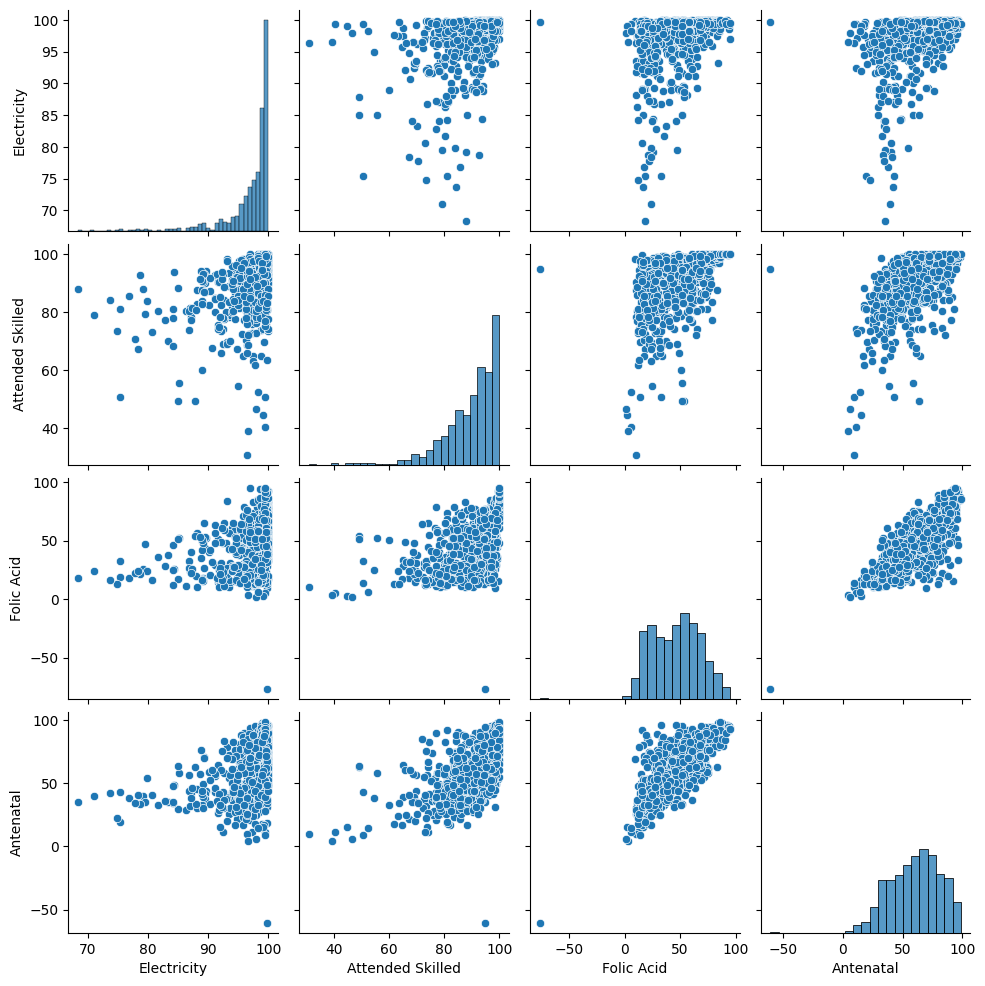

In [77]:
sns.pairplot(df)

In [79]:
X = df.drop('Postnatal', axis=1)
y = df['Postnatal']

In [80]:
X.head()

,Electricity,Attended Skilled,Folic Acid,Antenatal
0,97.9,98.6,72.6,71.7
1,93.2,98.3,83.7,79.2
2,99.6,96.9,81.0,85.9
3,99.9,96.4,67.5,78.4
4,99.5,97.6,59.6,71.4


In [81]:
y.head()

0    Medium
1      High
2      High
3      High
4    Medium
Name: Postnatal, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

In [82]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

[[30  0 13]
 [ 5 39  8]
 [16  5 26]]
              precision    recall  f1-score   support

        High       0.59      0.70      0.64        43
         Low       0.89      0.75      0.81        52
      Medium       0.55      0.55      0.55        47

    accuracy                           0.67       142
   macro avg       0.68      0.67      0.67       142
weighted avg       0.69      0.67      0.67       142



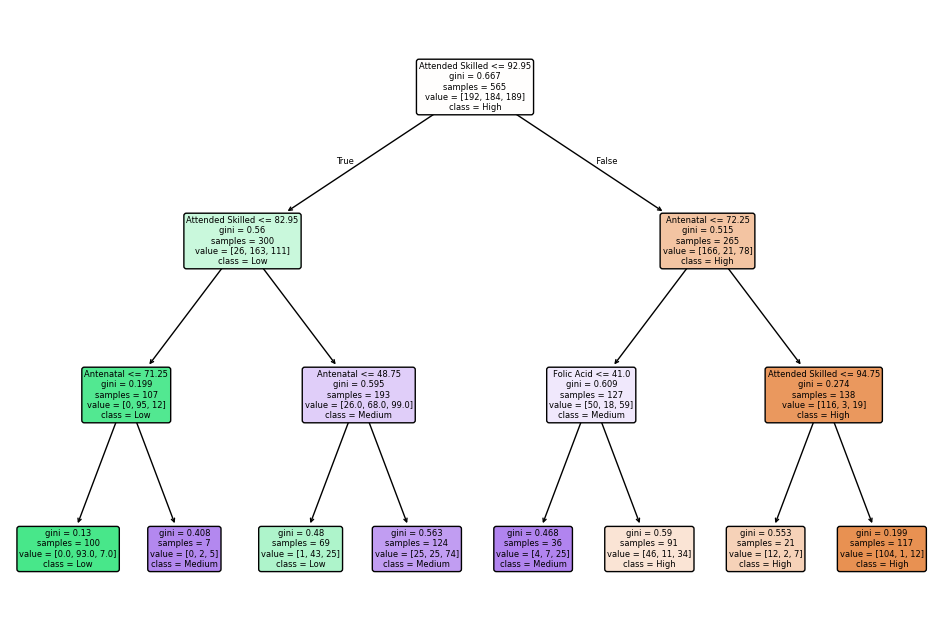

In [83]:
# Train a decision tree classifier
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)

clf.fit(X_train, y_train)

# Predict on the test set
y_pred = clf.predict(X_test)

# Evaluate the model
from sklearn.metrics import classification_report, confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(classification_report(y_test, y_pred))

# Visualize the decision tree
from sklearn.tree import plot_tree
plt.figure(figsize=(12, 8))
plot_tree(clf, filled=True, feature_names=X.columns, class_names=clf.classes_, rounded=True)
plt.show()


Text(50.722222222222214, 0.5, 'True Label')

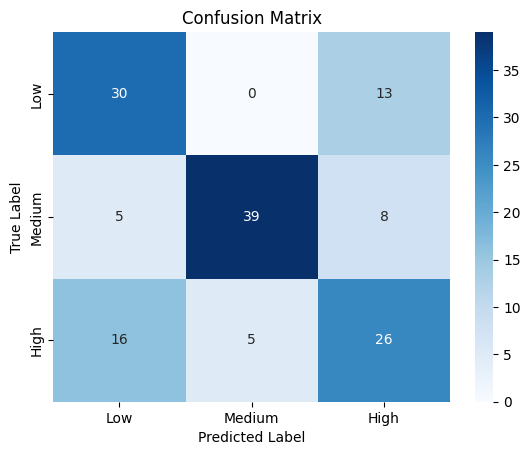

In [70]:
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
            xticklabels=["Low", "Medium", "High"], 
            yticklabels=["Low", "Medium", "High"])

# Set the title of the heatmap visualization.
plt.title('Confusion Matrix')  # Title for the heatmap

# Label the x-axis and y-axis with appropriate descriptions.
plt.xlabel('Predicted Label')  # Label for the x-axis
plt.ylabel('True Label')  # Label for the y-axis
